In [6]:
import pandas as pd

import sys
!{sys.executable} -m pip install xlrd
df = pd.read_excel("Sample - Superstore.xls", engine='xlrd')

df.head()


  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached xlrd-2.0.2-py2.py3-none-any.whl (96 kB)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [10]:
df["Year"] = df["Order Date"].dt.year

In [11]:
df["Month"] = df["Order Date"].dt.month_name()

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Business q

In [13]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

region in the west has highest sales 

In [14]:
df.groupby("Category")["Profit"].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

Technology has highest profit 

In [16]:
df.groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

Money is lossed in the table sub category 

In [17]:
df.groupby("Customer Name")["Sales"].sum().nlargest(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

this are the top 10 customers 


Monthly sales

In [18]:
df.groupby("Month")["Sales"].sum()

Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

In [19]:
df[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


highest sales

In [20]:
import sqlite3

conn = sqlite3.connect("store.db")

df.to_sql("Orders", conn, if_exists="replace", index=False)

query = """
SELECT Region,
SUM(Sales) AS TotalSales
FROM Orders
GROUP BY Region
ORDER BY TotalSales DESC;
"""

pd.read_sql(query, conn)



,Region,TotalSales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


Highest profit category 

In [22]:
query = """
SELECT Category,
       SUM(Profit) AS Total_Profit
FROM Orders
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

highest_profit = pd.read_sql(query, conn)
highest_profit

,Category,Total_Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


Loswest profit 

In [23]:
query = """
SELECT "Sub-Category",
       SUM(Profit) AS Total_Profit
FROM Orders
GROUP BY "Sub-Category"
ORDER BY Total_Profit ASC;
"""

lowest_profit = pd.read_sql(query, conn)
lowest_profit

,Sub-Category,Total_Profit
0,Tables,-17725.4811
1,Bookcases,-3472.5560
2,Supplies,-1189.0995
3,Fasteners,949.5182
4,Machines,3384.7569
5,Labels,5546.2540
6,Art,6527.7870
7,Envelopes,6964.1767
8,Furnishings,13059.1436
9,Appliances,18138.0054


Average discount 

In [24]:
query = """
SELECT Category,
       ROUND(AVG(Discount), 2) AS Average_Discount
FROM Orders
GROUP BY Category
ORDER BY Average_Discount DESC;
"""

average_discount = pd.read_sql(query, conn)
average_discount

,Category,Average_Discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


Top 10 customer

In [25]:
query = """
SELECT "Customer Name",
       SUM(Sales) AS Total_Sales
FROM Orders
GROUP BY "Customer Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, conn)
top_customers

,Customer Name,Total_Sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


Chart 1 sales by region

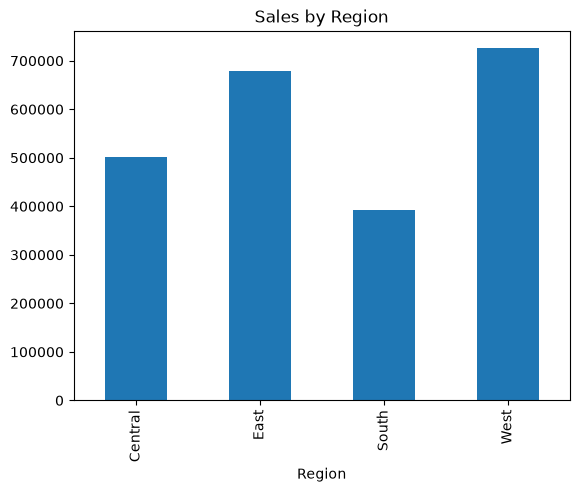

In [26]:
import matplotlib.pyplot as plt

df.groupby("Region")["Sales"].sum().plot(kind="bar")

plt.title("Sales by Region")
plt.show()

Chart 2 profit by category

<Axes: xlabel='Category'>

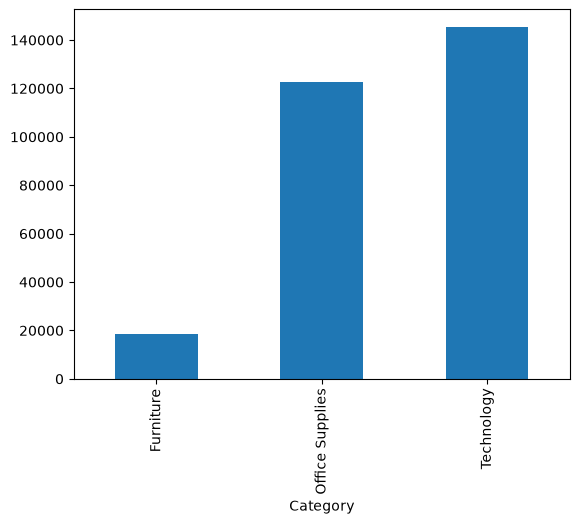

In [27]:
df.groupby("Category")["Profit"].sum().plot(kind="bar")

Chart 3 monthly sales

<Axes: xlabel='Month'>

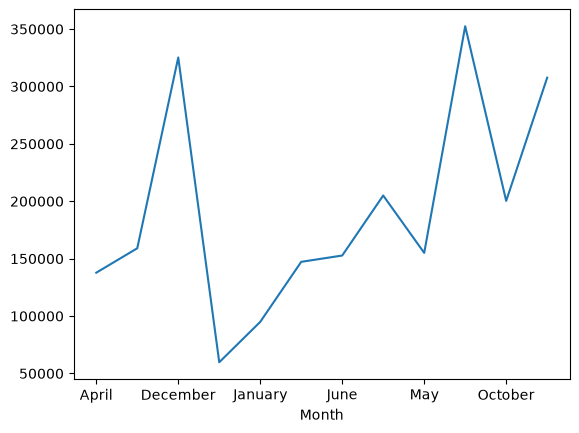

In [28]:
monthly = df.groupby("Month")["Sales"].sum()

monthly.plot(kind="line")

Chart discount vs profit 


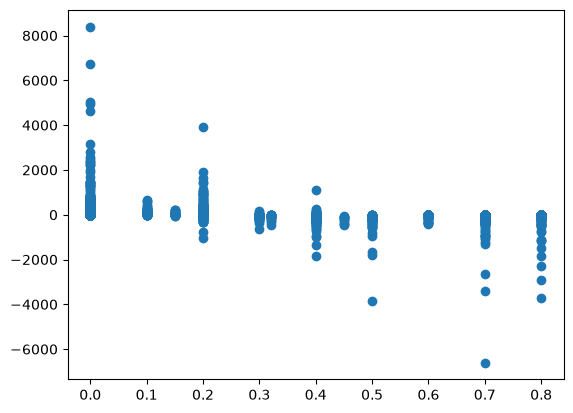

In [29]:
plt.scatter(df["Discount"],df["Profit"])

chart5 top 10 customer

<Axes: ylabel='Customer Name'>

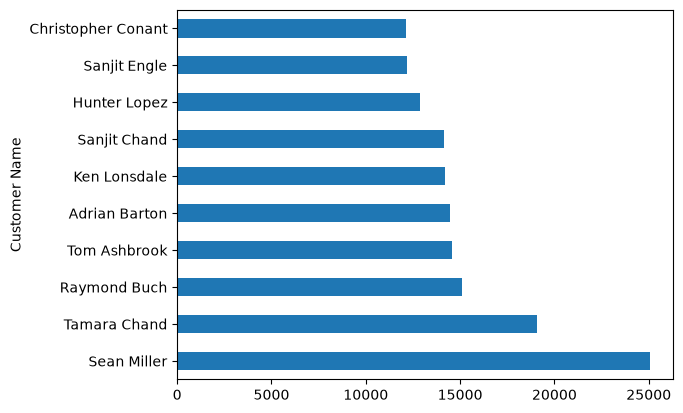

In [30]:
top = df.groupby("Customer Name")["Sales"].sum().nlargest(10)

top.plot(kind="barh")

Business Insights:

1. West region contributes highest revenue.

2. Technology category generates highest profit.

3. Furniture has several loss-making products.

4. High discounts reduce profit.

5. A small group of customers contributes significant revenue.

## Recommendations

Reduce discount on Furniture.

Increase marketing in West region.

Promote Technology products.

Retain top customers using loyalty programs.

Improve pricing for loss-making sub-categories.

# Executive Summary

## Objective
Analyze e-commerce sales data to identify trends and improve profitability.

## Dataset
Sample Superstore Dataset

## Key Findings
- West region has the highest sales.
- Technology is the most profitable category.
- Furniture contributes most losses.
- Discounts negatively affect profits.
- Top customers account for a large share of revenue.

## Recommendations
- Reduce excessive discounting.
- Increase investment in profitable categories.
- Focus retention efforts on high-value customers.
- Optimize pricing for low-performing sub-categories.

## Business Impact
These recommendations can improve profit margins, reduce losses, and support better decision-making.